# Autoresearch Experiment Analysis

Analysis of autonomous trading strategy optimization results from `results.tsv`.

**Setup**: `pip install pandas matplotlib`

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("results.tsv", sep="\t")
df["idx"] = range(len(df))
print(f"Loaded {len(df)} experiments")
df.head()

Loaded 779 experiments


,commit,avg_score,datasets,status,description,idx
0,a00b061,9.69,7,keep,baseline,0
1,40fd8c3,32.43,7,keep,"EMA 8/21, bb 1.8, cooldown 5, composite thresh...",1
2,0b15d3b,40.41,7,keep,stakePercent 0.08,2
3,8394f2f,48.99,7,keep,stakePercent 0.10,3
4,5ced659,56.43,7,keep,stakePercent 0.12,4


In [3]:
# Experiment outcomes
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())
print(f"\nKeep rate: {counts.get('keep', 0) / len(df) * 100:.1f}%")

Experiment outcomes:
status
discard                                    628
keep                                       149
live                                         1
winning-regime trigger 3pct (identical)      1

Keep rate: 19.1%


## Score Trajectory

Track how avg_score evolves as experiments progress. Green = kept, Red = discarded.

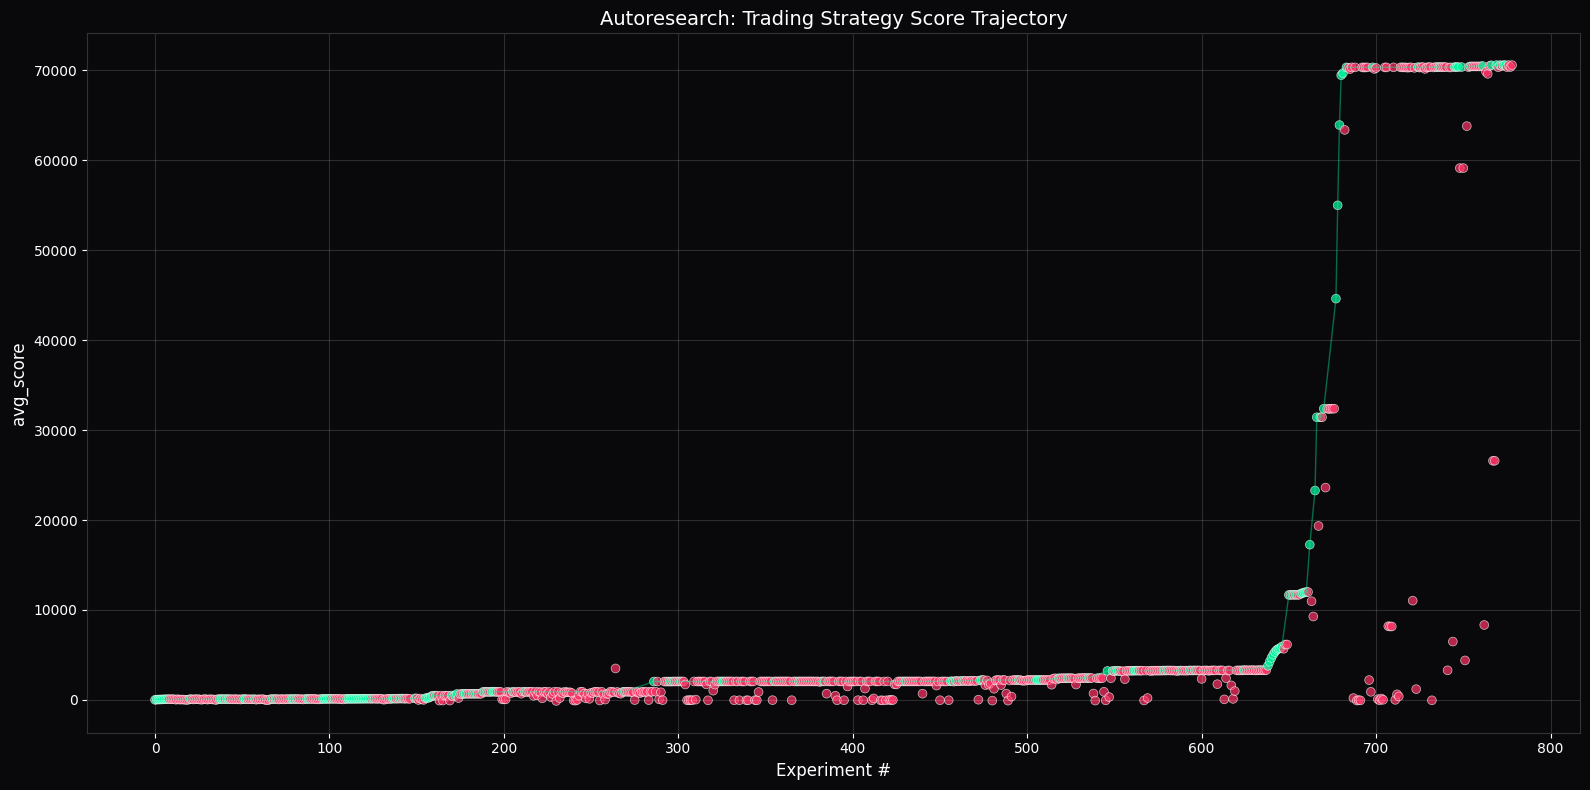

In [4]:
fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "crash"].copy()
colors = ["#00FFA3" if s == "keep" else "#FF3366" for s in valid["status"]]

ax.scatter(valid["idx"], valid["avg_score"], c=colors, s=40, alpha=0.7, edgecolors="white", linewidth=0.5)

# Connect kept experiments
kept = valid[valid["status"] == "keep"]
if len(kept) > 1:
    ax.plot(kept["idx"], kept["avg_score"], color="#00FFA3", alpha=0.4, linewidth=1)

ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("avg_score", fontsize=12)
ax.set_title("Autoresearch: Trading Strategy Score Trajectory", fontsize=14)
ax.set_facecolor("#09090B")
fig.set_facecolor("#09090B")
ax.tick_params(colors="white")
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")
ax.title.set_color("white")
for spine in ax.spines.values():
    spine.set_color("#333")
ax.grid(True, alpha=0.15, color="white")

plt.tight_layout()
plt.show()

## Best Score Progression

Running maximum of kept experiments — the optimization frontier.

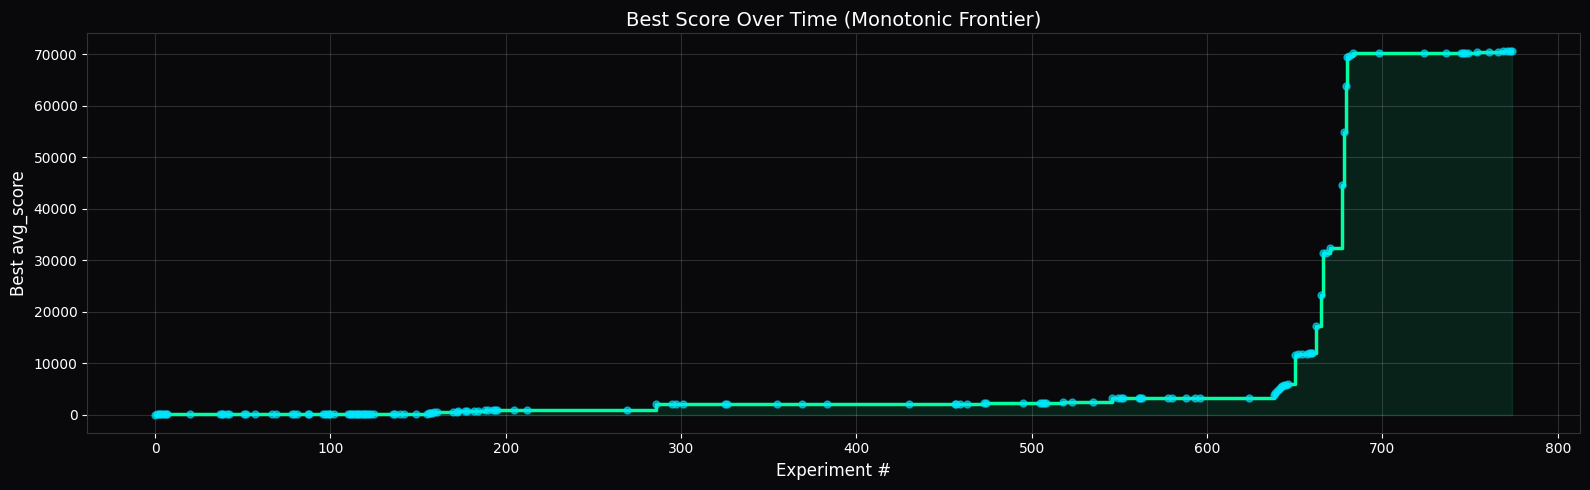

In [5]:
kept = df[df["status"] == "keep"].copy()
if len(kept) > 0:
    kept["best_so_far"] = kept["avg_score"].cummax()

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.step(kept["idx"], kept["best_so_far"], color="#00FFA3", linewidth=2.5, where="post")
    ax.fill_between(kept["idx"], kept["best_so_far"], alpha=0.1, color="#00FFA3", step="post")
    ax.scatter(kept["idx"], kept["avg_score"], color="#00E5FF", s=25, alpha=0.6, zorder=5)

    ax.set_xlabel("Experiment #", fontsize=12)
    ax.set_ylabel("Best avg_score", fontsize=12)
    ax.set_title("Best Score Over Time (Monotonic Frontier)", fontsize=14)
    ax.set_facecolor("#09090B")
    fig.set_facecolor("#09090B")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    for spine in ax.spines.values():
        spine.set_color("#333")
    ax.grid(True, alpha=0.15, color="white")

    plt.tight_layout()
    plt.show()
else:
    print("No kept experiments yet.")

## Summary Statistics

In [6]:
kept = df[df["status"] == "keep"].copy()
baseline_score = df.iloc[0]["avg_score"] if len(df) > 0 else 0

print(f"Total experiments:    {len(df)}")
print(f"Kept:                {len(df[df['status'] == 'keep'])}")
print(f"Discarded:           {len(df[df['status'] == 'discard'])}")
print(f"Crashed:             {len(df[df['status'] == 'crash'])}")
print(f"Keep rate:           {len(df[df['status'] == 'keep']) / max(len(df), 1) * 100:.1f}%")
print(f"")
print(f"Baseline score:      {baseline_score}")
print(f"Best score:          {df['avg_score'].max():.2f}")
print(f"Improvement:         +{df['avg_score'].max() - baseline_score:.2f} ({(df['avg_score'].max() - baseline_score) / max(abs(baseline_score), 0.01) * 100:.1f}%)")
print(f"")
if len(kept) > 0:
    best_row = kept.loc[kept["avg_score"].idxmax()]
    print(f"Best experiment:     {best_row['description']}")
    print(f"Best commit:         {best_row['commit']}")

Total experiments:    779
Kept:                149
Discarded:           628
Crashed:             0
Keep rate:           19.1%

Baseline score:      9.69
Best score:          70576.11
Improvement:         +70566.42 (728239.6%)

Best experiment:     mid-vol boundary 0.0003 (+1.17)
Best commit:         9209678


## Top Improvements (Kept Experiments by Score)

In [7]:
kept = df[df["status"] == "keep"].copy()
if len(kept) > 1:
    kept["delta"] = kept["avg_score"].diff()
    top = kept.dropna(subset=["delta"]).nlargest(10, "delta")
    print("Top 10 improvements:\n")
    for _, row in top.iterrows():
        print(f"  +{row['delta']:.2f}  →  {row['avg_score']:.2f}  |  {row['description']}")
else:
    print("Not enough kept experiments for delta analysis.")

Top 10 improvements:

  +12235.63  →  44612.43  |  stakePercent 0.45 (m4=312434!)
  +10376.88  →  54989.31  |  stakePercent 0.50 (m4=385133)
  +8925.04  →  63914.35  |  stakePercent 0.55 (m4=447561)
  +8148.35  →  31426.32  |  midGame start tick 130 factor 0.02 (m4=219663!)
  +6019.76  →  23277.97  |  midGame start tick 125 factor 0.02 (massive!)
  +5735.98  →  11673.62  |  lateGameTick 220 (massive boost to m4)
  +5539.79  →  69454.14  |  stakePercent 0.60 (m4=486256)
  +5258.43  →  17258.21  |  midGame start tick 120 factor 0.02 (massive jump)
  +1130.00  →  2043.16  |  adaptive threshold (m4 +14564: winning→0.20, losing→0.35; m7 -82, m2 -92 concern)
  +948.65  →  32376.80  |  midGame freeze from tick 132 factor 0 (m4=226657)
